In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(50)

#Generate 50 features and 100 rows
n_rows =  100
n_features = 50
X = np.random.randint(1,10,size=(n_rows, n_features))
weights =np.random.randint(1000,10000, size=n_features)
noise = np.random.randint(-5000,5000,size=n_rows)
y= X.dot(weights) + noise

feature_names =[f'Feature_{i+1}' for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df['Price'] = y

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 51 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Feature_1   100 non-null    int32
 1   Feature_2   100 non-null    int32
 2   Feature_3   100 non-null    int32
 3   Feature_4   100 non-null    int32
 4   Feature_5   100 non-null    int32
 5   Feature_6   100 non-null    int32
 6   Feature_7   100 non-null    int32
 7   Feature_8   100 non-null    int32
 8   Feature_9   100 non-null    int32
 9   Feature_10  100 non-null    int32
 10  Feature_11  100 non-null    int32
 11  Feature_12  100 non-null    int32
 12  Feature_13  100 non-null    int32
 13  Feature_14  100 non-null    int32
 14  Feature_15  100 non-null    int32
 15  Feature_16  100 non-null    int32
 16  Feature_17  100 non-null    int32
 17  Feature_18  100 non-null    int32
 18  Feature_19  100 non-null    int32
 19  Feature_20  100 non-null    int32
 20  Feature_21  100 non-null    int32

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_42,Feature_43,Feature_44,Feature_45,Feature_46,Feature_47,Feature_48,Feature_49,Feature_50,Price
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.0000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,4.870000,4.770000,4.830000,5.470000,5.11000,4.740000,5.300000,5.140000,4.940000,5.100000,...,5.4800,5.160000,5.050000,5.070000,5.220000,4.830000,4.990000,4.730000,5.230000,1.596864e+06
std,2.650157,2.534031,2.590016,2.709709,2.53419,2.588319,2.472066,2.647736,2.473373,2.512595,...,2.6533,2.460681,2.362908,2.637166,2.668863,2.558626,2.532596,2.453013,2.627958,1.271996e+05
min,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.304230e+06
25%,2.000000,2.000000,2.000000,3.000000,3.00000,3.000000,4.000000,3.000000,3.000000,3.000000,...,3.0000,3.750000,3.750000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.493365e+06
50%,5.000000,5.000000,5.000000,6.000000,5.00000,4.000000,5.000000,6.000000,5.000000,5.000000,...,6.0000,5.000000,5.000000,5.000000,5.500000,5.000000,5.000000,4.500000,5.000000,1.605627e+06
75%,7.000000,7.000000,7.000000,8.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,...,8.0000,7.000000,7.000000,7.000000,8.000000,7.000000,7.000000,7.000000,8.000000,1.699038e+06
max,9.000000,9.000000,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.0000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,1.870264e+06


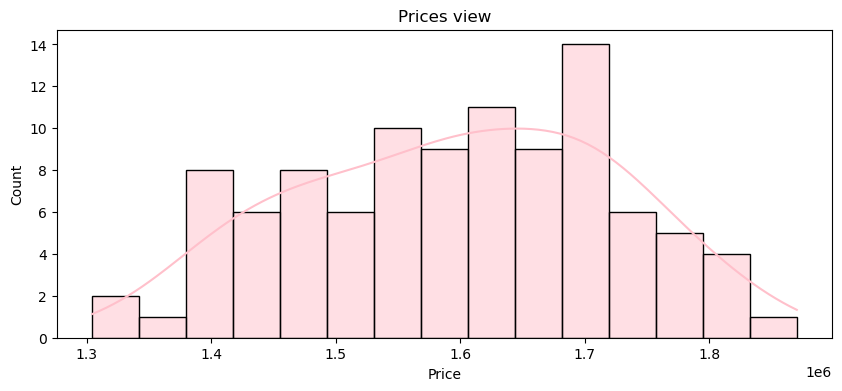

In [5]:
plt.figure(figsize=(10,4))
sns.histplot(df['Price'], bins=15, kde=True, color='pink')
plt.title("Prices view")
plt.show()


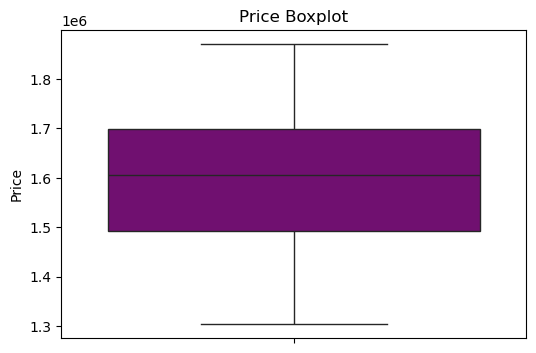

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Price'], color ='purple')
plt.title("Price Boxplot")
plt.show()

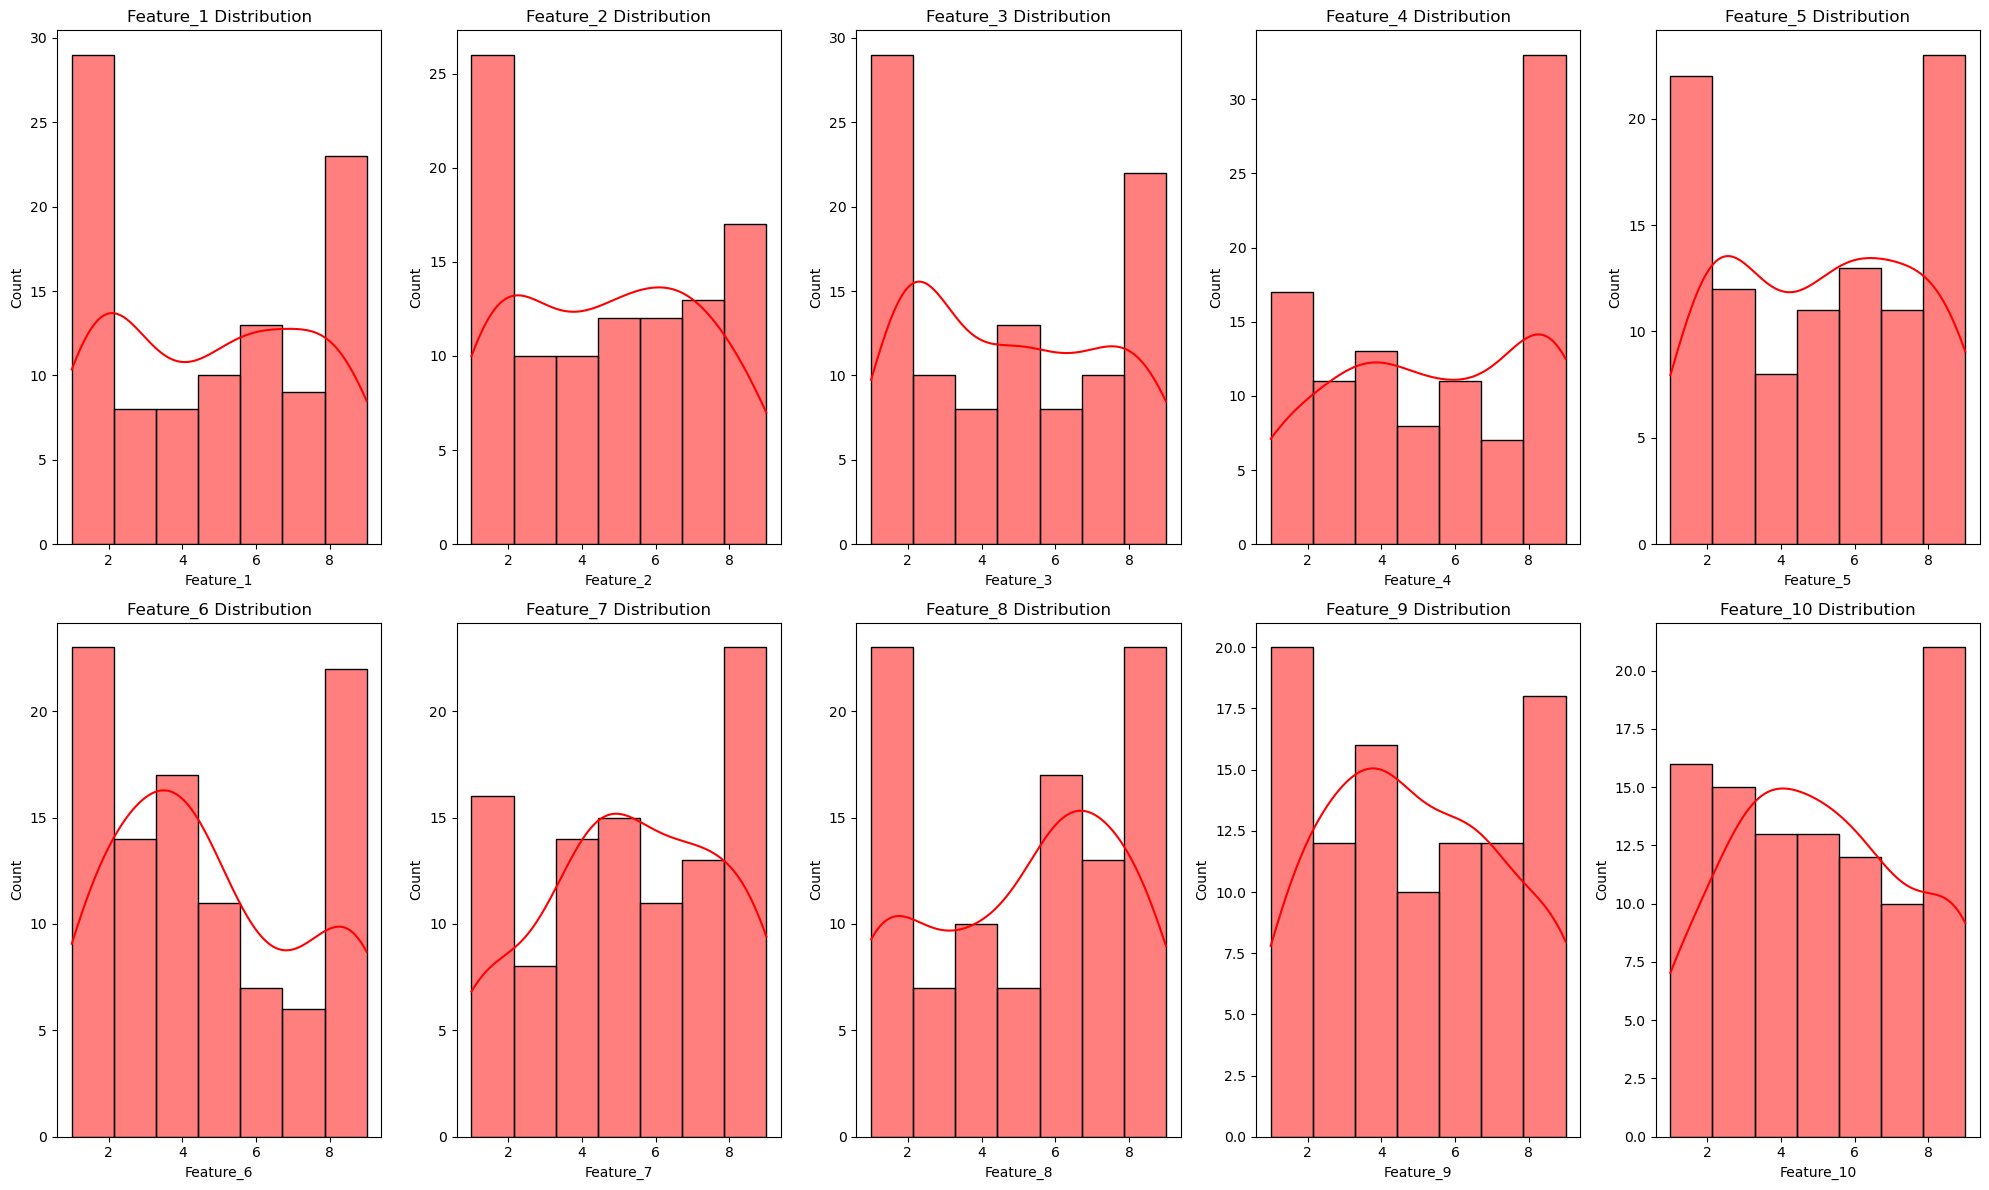

In [7]:
plt.figure(figsize=(20,12))
for i, f in enumerate(df.columns[:10]):
    plt.subplot(2,5,i+1)
    sns.histplot(df[f], bins=7, kde=True, color='red')
    plt.title(f"{f} Distribution")
plt.tight_layout()
plt.show()


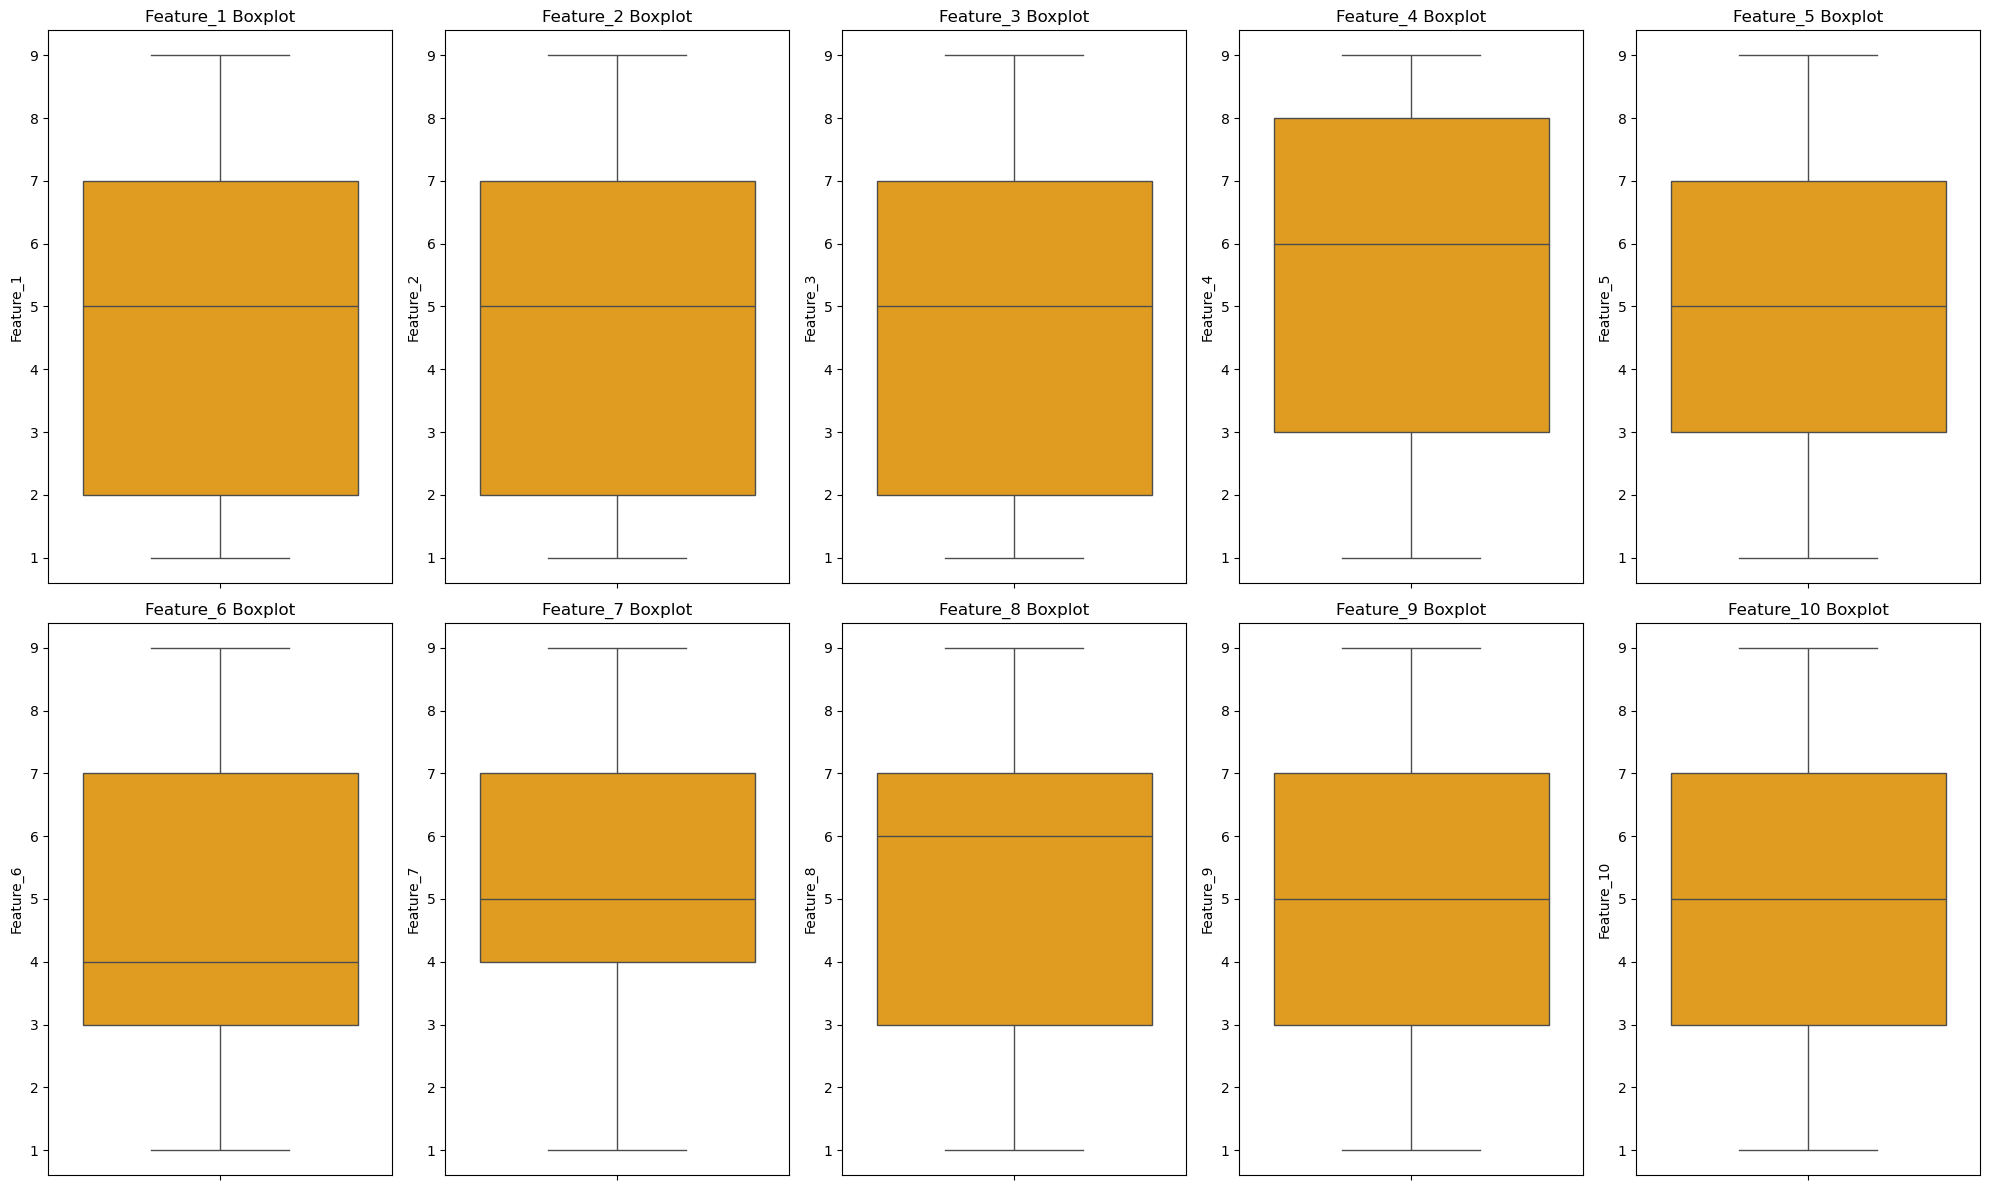

In [8]:
plt.figure(figsize=(20,12))
for i, f in enumerate(df.columns[:10]):
    plt.subplot(2,5,i+1)
    sns.boxplot(y=df[f], color='orange')
    plt.title(f"{f} Boxplot")
plt.tight_layout()
plt.show()

In [9]:
X=df.drop('Price', axis=1)
y= df['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=42)

In [10]:
scaler =StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

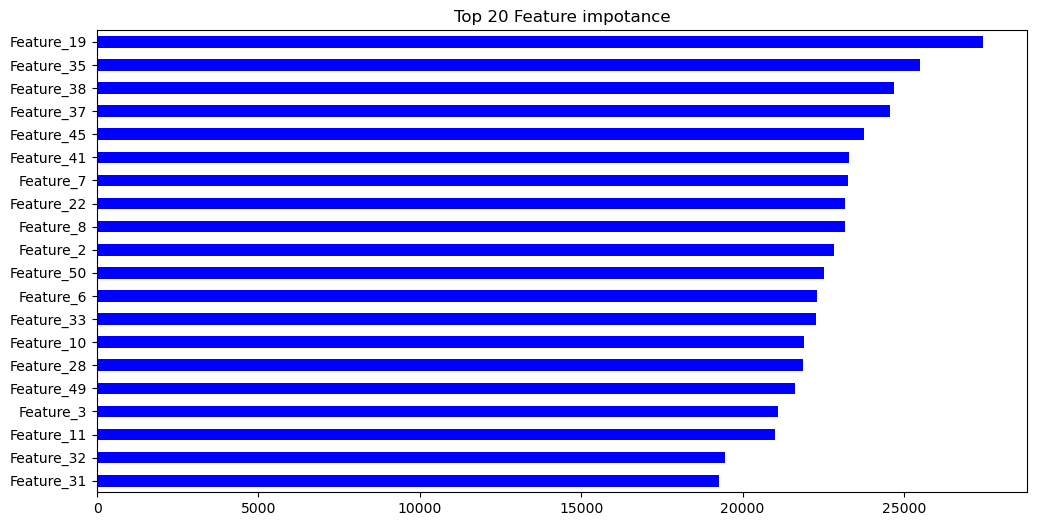

In [12]:
importances= pd.Series(np.abs(model.coef_), index=X.columns)
importances.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(12,6))
importances.head(20).plot(kind='barh', color='blue')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature impotance")
plt.show()


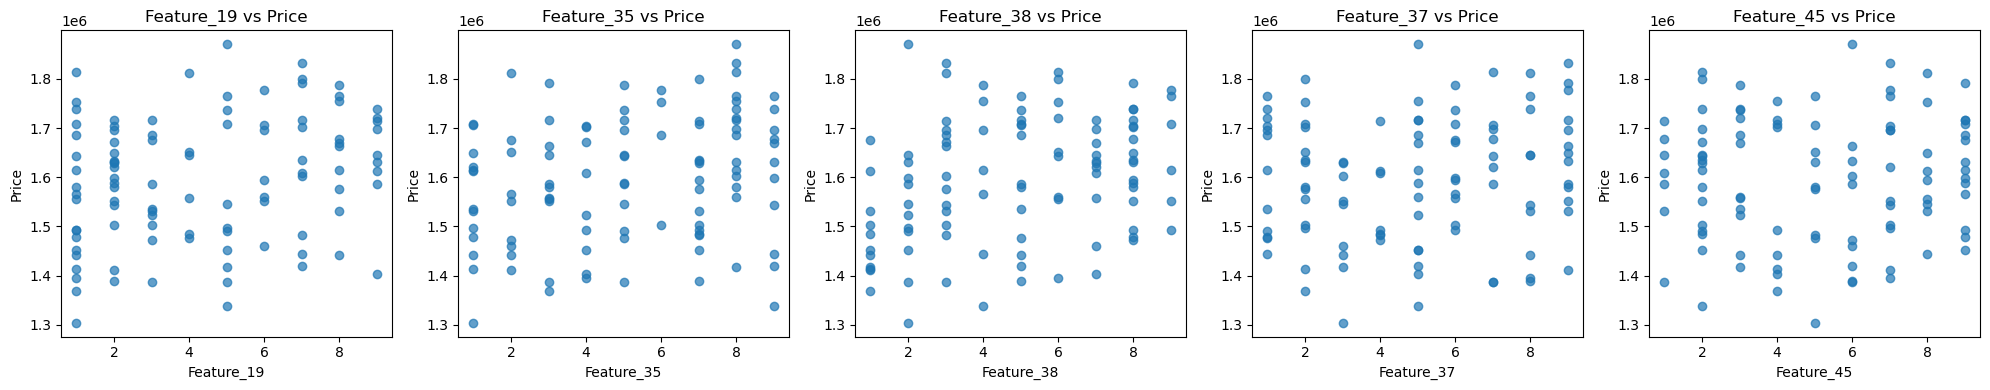

In [16]:
top_5 = importances.head(5).index
plt.figure(figsize=(20,4))
for i , f in enumerate(top_5):
    plt.subplot(1,5,i+1)
    plt.scatter(df[f], df['Price'], alpha=0.7)
    plt.xlabel(f)
    plt.ylabel("Price")
    plt.title(f"{f} vs Price")
plt.tight_layout()
plt.show()

    

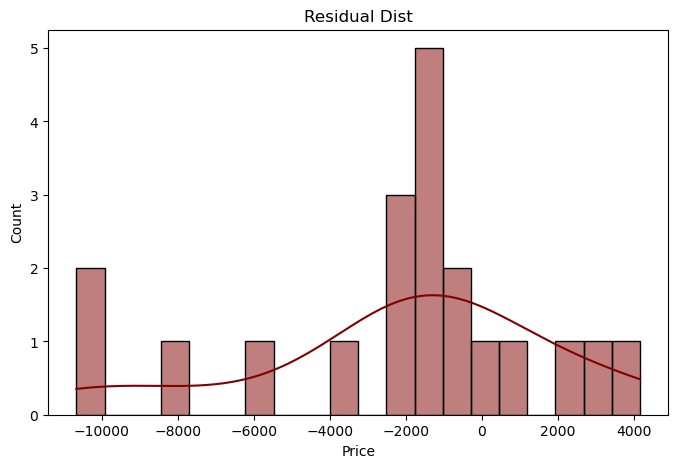

In [18]:
residuals = y_test- y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=20, kde=True , color='maroon')
plt.title("Residual Dist")
plt.show()

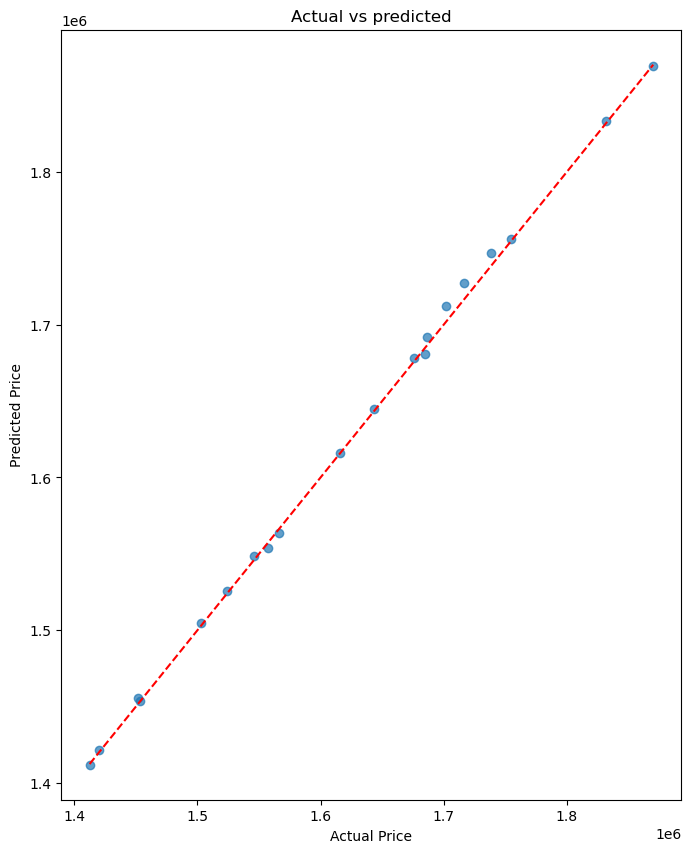

In [21]:
plt.figure(figsize=(8,10))
plt.scatter(y_test, y_pred ,alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs predicted")
plt.show()

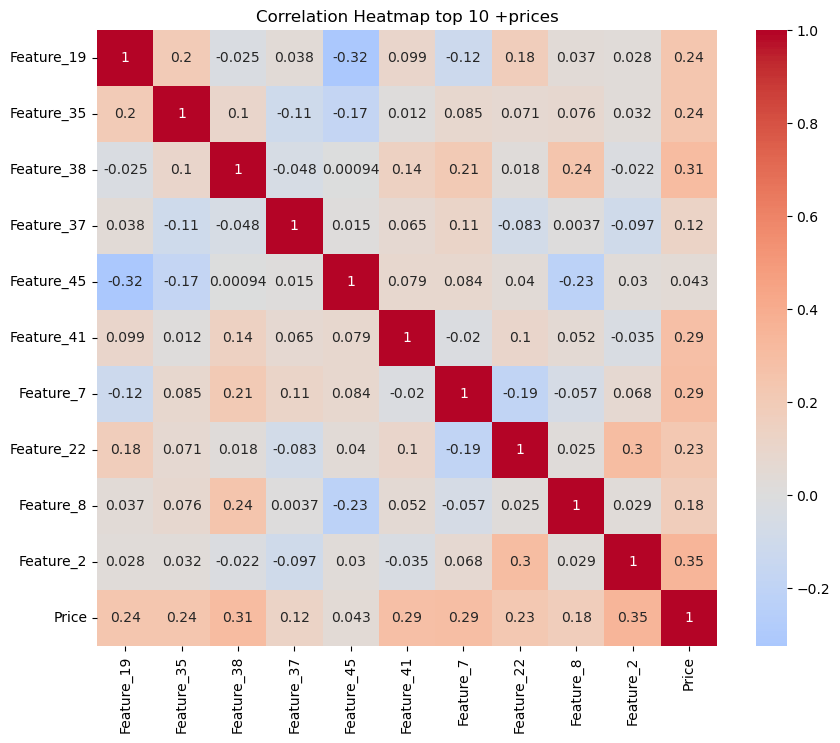

In [48]:
top_10 =importances.head(10).index
plt.figure(figsize=(10,8))
sns.heatmap(df[top_10.tolist() +['Price']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap top 10 +prices")
plt.show()

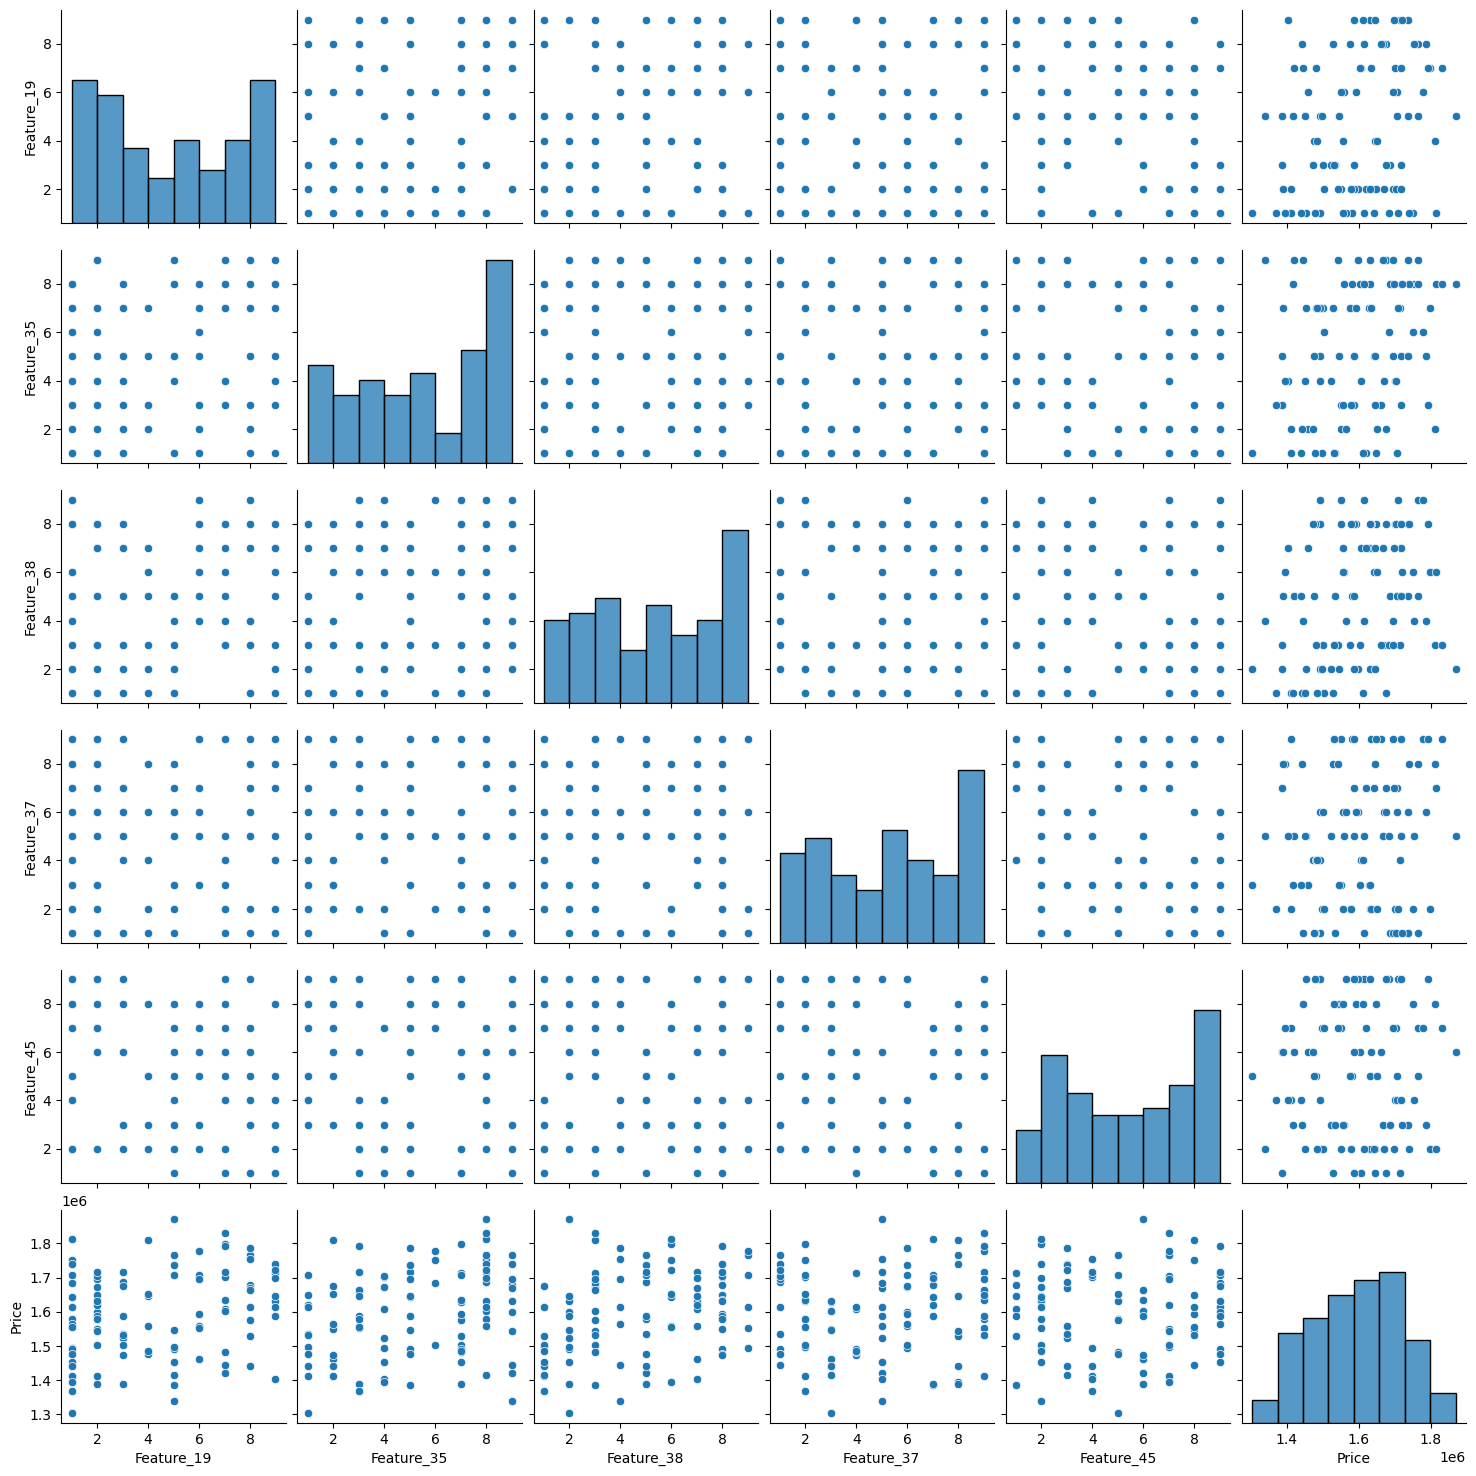

In [23]:
sns.pairplot(df[top_5.tolist()+ ['Price']])
plt.show()

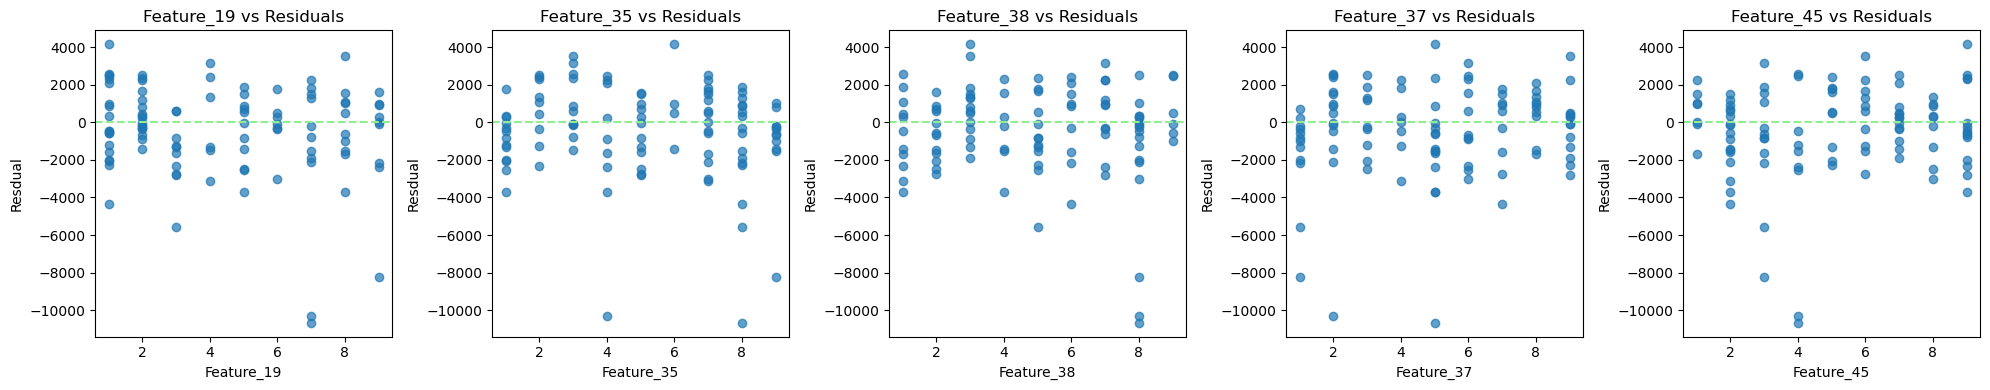

In [25]:
plt.figure(figsize=(20,4))
for i , f in enumerate(top_5):
    plt.subplot(1,5,i+1)
    res=df['Price'] - model.predict(scaler.transform(df.drop('Price' ,axis=1)))
    plt.axhline(0, color='lightgreen', linestyle='--')
    plt.scatter(df[f], res, alpha=0.7)
    plt.xlabel(f)
    plt.ylabel("Resdual")
    plt.title(f"{f} vs Residuals")
plt.tight_layout()
plt.show()

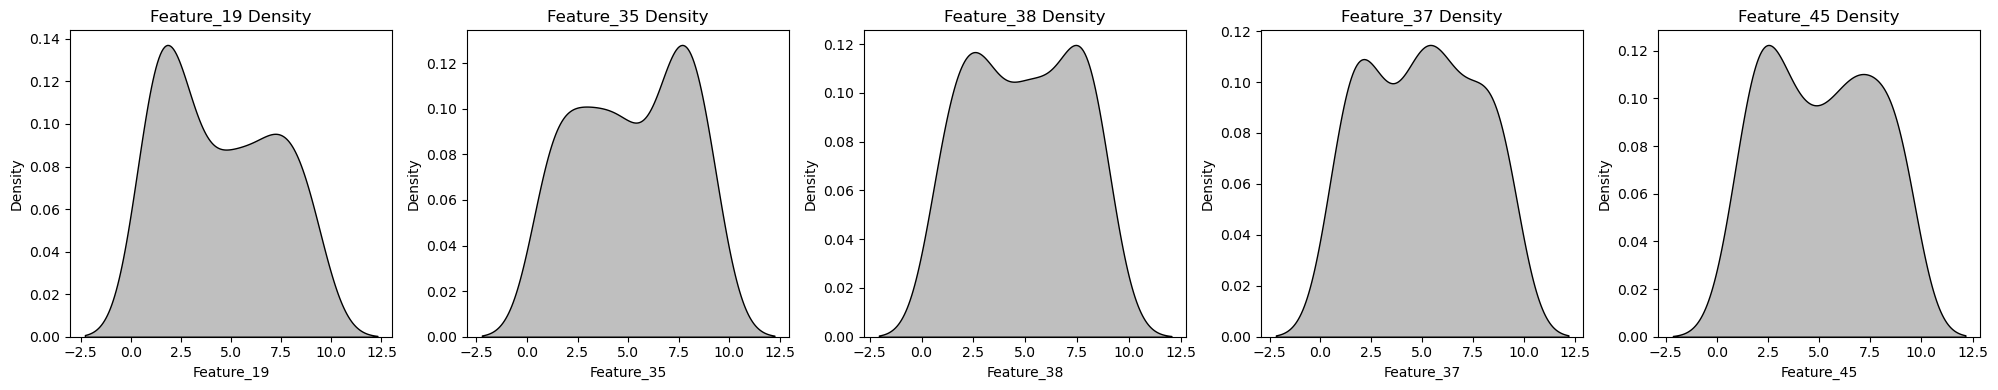

In [30]:
plt.figure(figsize=(20,4))
for i, f in enumerate(top_5):
    plt.subplot(1,5,i+1)
    sns.kdeplot(df[f], fill=True, color='black')
    plt.title(f"{f} Density")
plt.tight_layout()
plt.show()

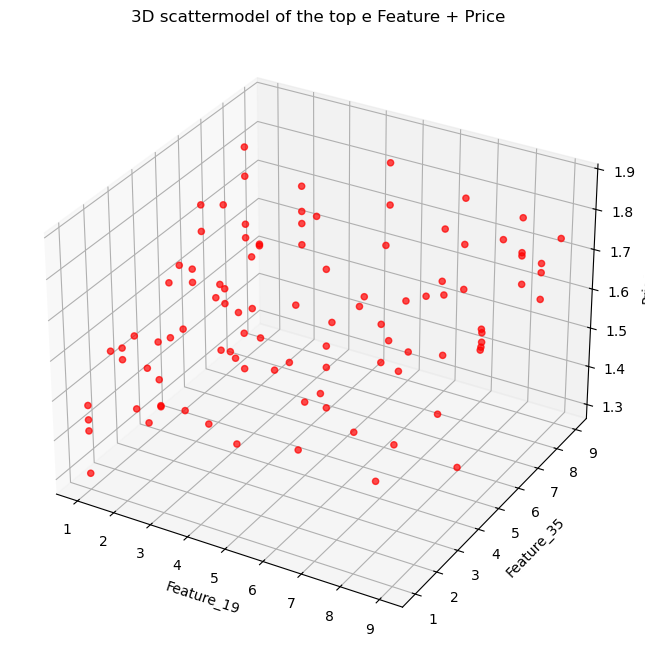

In [35]:
fig= plt.figure(figsize=(10,8))
ax =  fig.add_subplot(111, projection='3d')
ax.scatter(df[top_5[0]],df[top_5[1]],df['Price'], color='red', alpha=0.7)
ax.set_xlabel(top_5[0])
ax.set_ylabel(top_5[1])
ax.set_zlabel("Price")
ax.set_title("3D scattermodel of the top e Feature + Price")
plt.show()

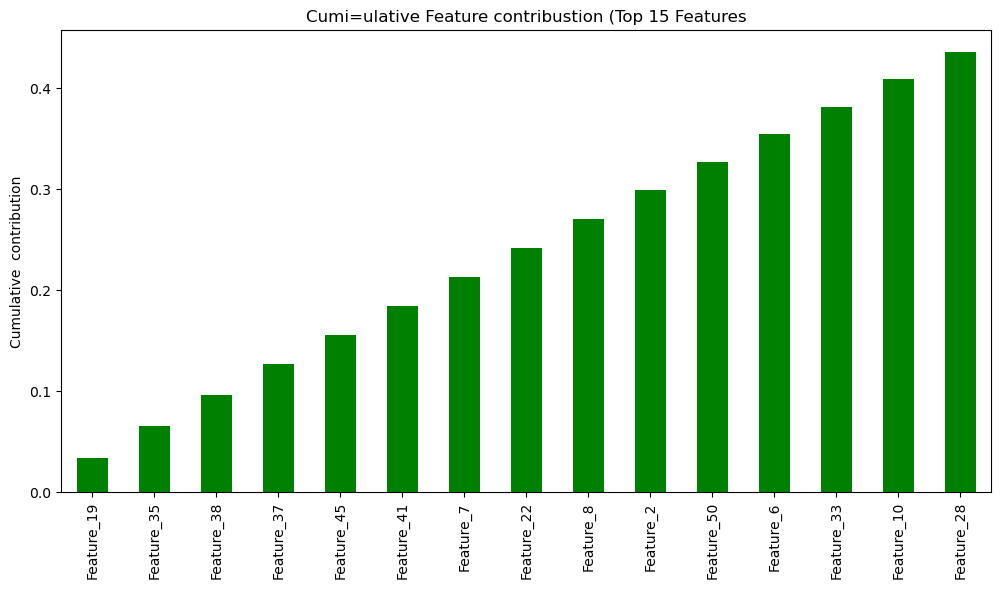

In [40]:
plt.figure(figsize=(12,6))
(importances.cumsum()/importances.sum()).head(15).plot(kind='bar' , color= 'green')
plt.title("Cumi=ulative Feature contribustion (Top 15 Features")
plt.ylabel("Cumulative  contribution")
plt.show()

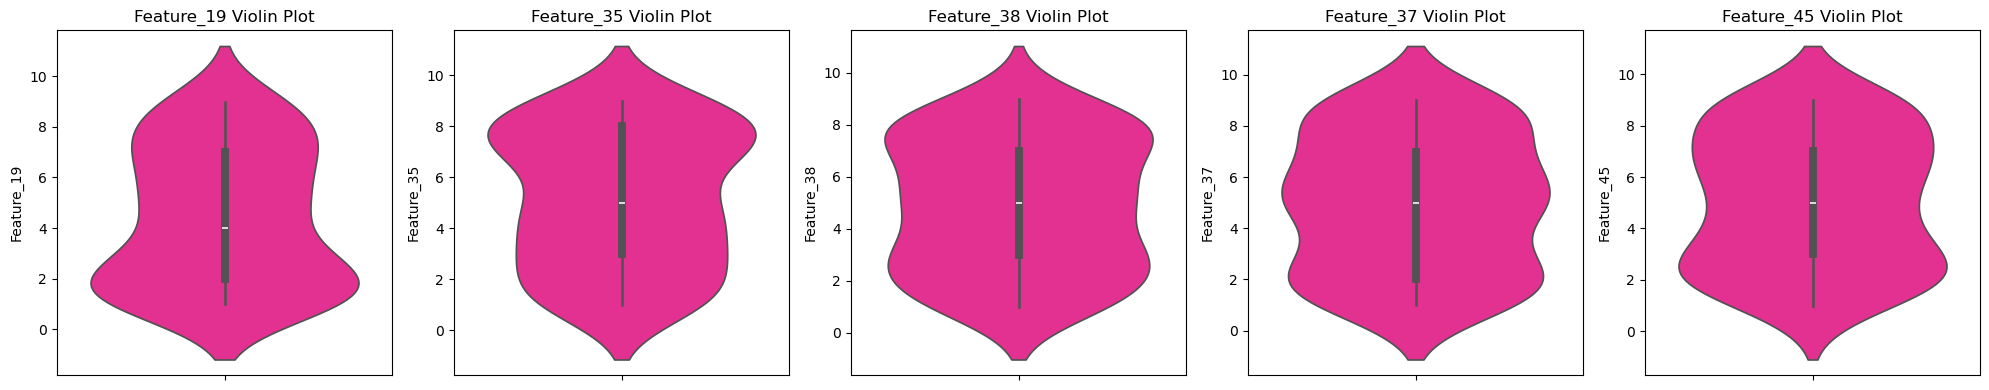

In [42]:
plt.figure(figsize=(20,4))
for i, f in enumerate(top_5):
    plt.subplot(1,5,i+1)
    sns.violinplot(y=df[f], color= 'deeppink')
    plt.title(f"{f} Violin Plot")
plt.tight_layout()
plt.show()

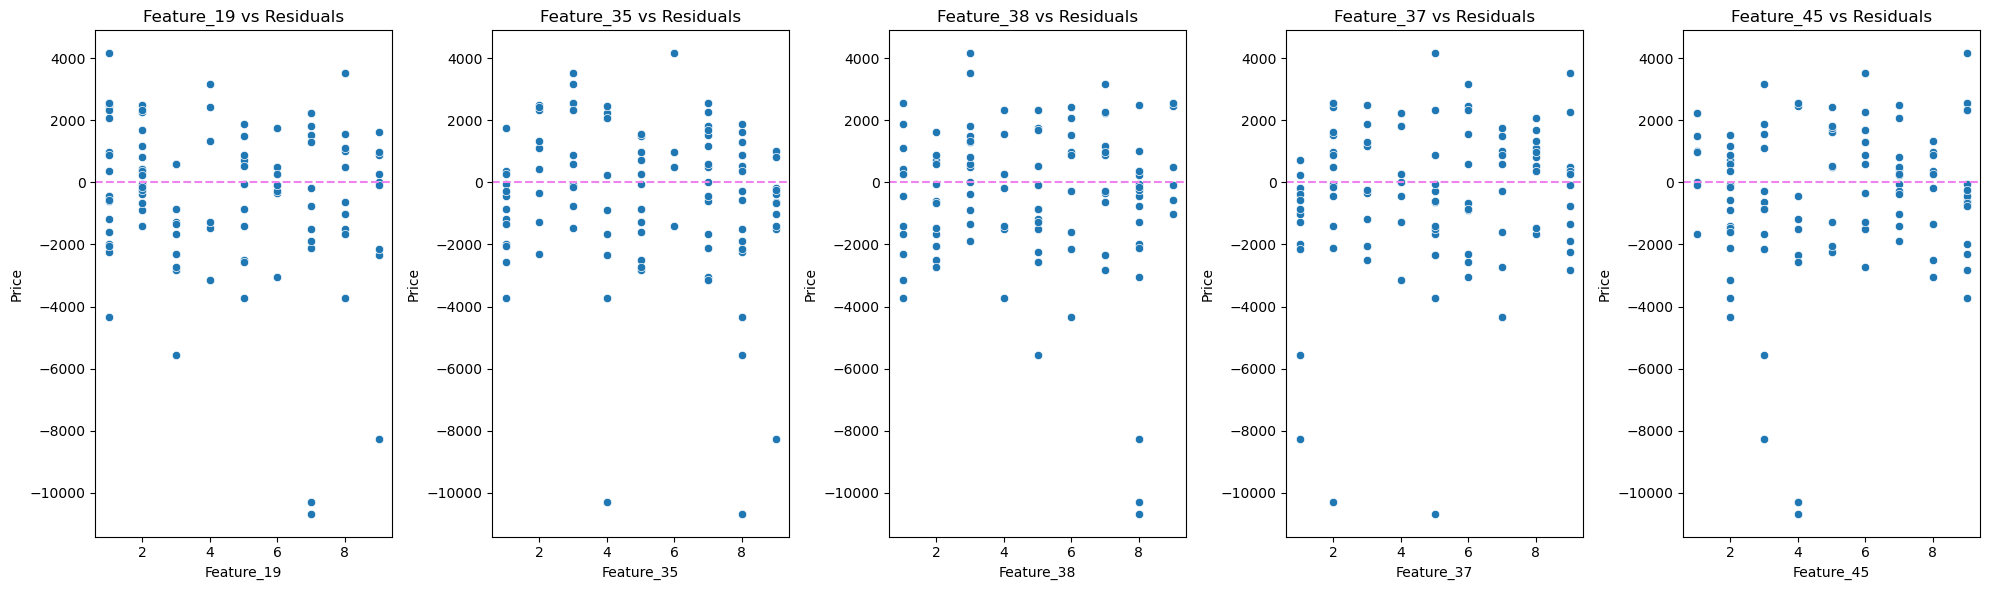

In [44]:
plt.figure(figsize=(20,6))
for i, f in enumerate(top_5):
    plt.subplot(1,5,i+1)
    res=df['Price'] - model.predict(scaler.transform(df.drop('Price', axis=1)))
    sns.scatterplot(x=df[f],y=res)
    plt.axhline(0,color='violet', linestyle='--')
    plt.title(f"{f} vs Residuals")
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

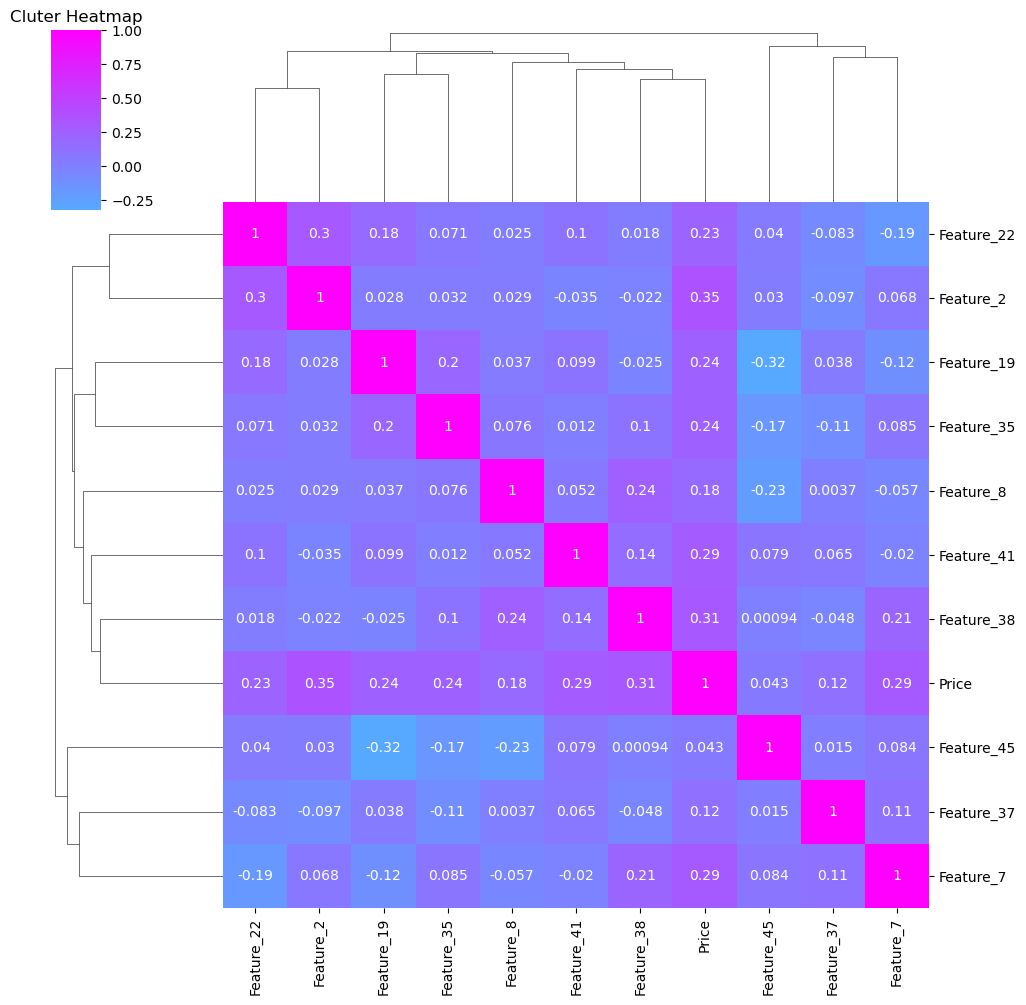

In [46]:
plt.figure(figsize=(12,10))
sns.clustermap(df[top_10.tolist()+['Price']].corr(), annot=True ,cmap='cool', center=0)
plt.title("Cluter Heatmap")
plt.show()